In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/supply_chain_demand.csv")

df.head()

,Order_ID,Order_Date,Product_ID,Product_Category,Product_Name,Region,City,Supplier_ID,Supplier_Lead_Time_Days,Warehouse_ID,...,Promotion,Holiday,Season,Weather,Competitor_Price,Stockout_Days,Delivery_Delay_Days,Transportation_Cost,Customer_Return_Rate,Demand_Quantity
0,ORD100000,2024-04-02,P-BEA-004,Beauty,Talcum Powder,North,Delhi,SUP-034,4.0,WH-NO-05,...,No,No,Summer,Sunny,1033.61,0.0,21.0,218.83,0.129,22
1,ORD100001,2023-02-19,P-CLO-006,Clothing,Cotton Saree,West,Surat,SUP-019,13.0,WH-WE-04,...,Yes,No,Spring,Sunny,618.38,0.0,2.0,476.26,0.021,29
2,ORD100002,2024-03-14,P-BEA-013,Beauty,Lipstick Set,West,Pune,SUP-028,11.0,WH-WE-02,...,No,No,Summer,Sunny,749.79,0.0,1.0,379.62,0.023,20
3,ORD100003,2021-10-26,P-FUR-002,Furniture,Study Table,North,Jaipur,SUP-039,2.0,WH-NO-05,...,No,Yes,Autumn,Rainy,7279.16,0.0,NaN,440.40,0.048,9
4,ORD100004,2022-01-27,P-ELE-002,Electronics,Smartphone Charger,North,Chandigarh,SUP-002,4.0,WH-NO-05,...,No,No,Winter,Sunny,5218.89,0.0,1.0,239.47,0.072,10


In [12]:
df.shape

(5000, 27)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 5000 non-null   object 
 1   Order_Date               5000 non-null   object 
 2   Product_ID               5000 non-null   object 
 3   Product_Category         5000 non-null   object 
 4   Product_Name             5000 non-null   object 
 5   Region                   5000 non-null   object 
 6   City                     4844 non-null   object 
 7   Supplier_ID              5000 non-null   object 
 8   Supplier_Lead_Time_Days  4847 non-null   float64
 9   Warehouse_ID             5000 non-null   object 
 10  Current_Inventory        4813 non-null   float64
 11  Previous_Day_Sales       4845 non-null   float64
 12  Previous_7_Days_Sales    4855 non-null   float64
 13  Previous_30_Days_Sales   4842 non-null   float64
 14  Average_Daily_Sales     

In [14]:
print(df.isnull().sum())

Order_ID                     0
Order_Date                   0
Product_ID                   0
Product_Category             0
Product_Name                 0
Region                       0
City                       156
Supplier_ID                  0
Supplier_Lead_Time_Days    153
Warehouse_ID                 0
Current_Inventory          187
Previous_Day_Sales         155
Previous_7_Days_Sales      145
Previous_30_Days_Sales     158
Average_Daily_Sales        100
Unit_Price                 101
Discount_Percentage        142
Promotion                  152
Holiday                    125
Season                     128
Weather                    248
Competitor_Price           107
Stockout_Days              182
Delivery_Delay_Days        173
Transportation_Cost        186
Customer_Return_Rate       169
Demand_Quantity              0
dtype: int64


In [15]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

Weather                    4.96
Current_Inventory          3.74
Transportation_Cost        3.72
Stockout_Days              3.64
Delivery_Delay_Days        3.46
Customer_Return_Rate       3.38
Previous_30_Days_Sales     3.16
City                       3.12
Previous_Day_Sales         3.10
Supplier_Lead_Time_Days    3.06
Promotion                  3.04
Previous_7_Days_Sales      2.90
Discount_Percentage        2.84
Season                     2.56
Holiday                    2.50
Competitor_Price           2.14
Unit_Price                 2.02
Average_Daily_Sales        2.00
dtype: float64


In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [17]:
df.describe()

,Supplier_Lead_Time_Days,Current_Inventory,Previous_Day_Sales,Previous_7_Days_Sales,Previous_30_Days_Sales,Average_Daily_Sales,Unit_Price,Discount_Percentage,Competitor_Price,Stockout_Days,Delivery_Delay_Days,Transportation_Cost,Customer_Return_Rate,Demand_Quantity
count,4847.000000,4813.000000,4845.000000,4855.000000,4842.000000,4900.000000,4899.000000,4858.000000,4893.000000,4818.000000,4827.000000,4814.000000,4831.000000,5000.000000
mean,8.783784,316.145439,21.810733,147.759629,634.772408,21.236957,3662.629324,12.522520,3622.897936,0.106061,1.240729,382.501545,0.089472,24.111600
std,4.489760,372.949800,20.417471,102.760857,435.750851,14.320757,4725.991403,8.273734,4606.632071,0.426154,2.054594,136.017370,0.060248,18.222084
min,1.000000,7.000000,0.000000,14.000000,63.000000,2.270000,50.880000,0.100000,42.900000,0.000000,0.000000,50.000000,0.001000,0.000000
25%,6.000000,113.000000,9.000000,68.000000,290.250000,9.777500,487.160000,6.000000,483.270000,0.000000,0.000000,301.070000,0.044000,11.000000
50%,8.000000,216.000000,16.000000,120.000000,522.000000,17.545000,1417.780000,11.000000,1404.250000,0.000000,1.000000,366.425000,0.077000,19.000000
75%,11.000000,409.000000,29.000000,201.000000,869.000000,29.045000,4864.685000,17.800000,4892.590000,0.000000,2.000000,444.245000,0.121000,32.000000
max,37.000000,8898.000000,379.000000,832.000000,3457.000000,107.620000,50145.940000,45.200000,24001.150000,8.000000,27.000000,2375.310000,0.404000,172.000000


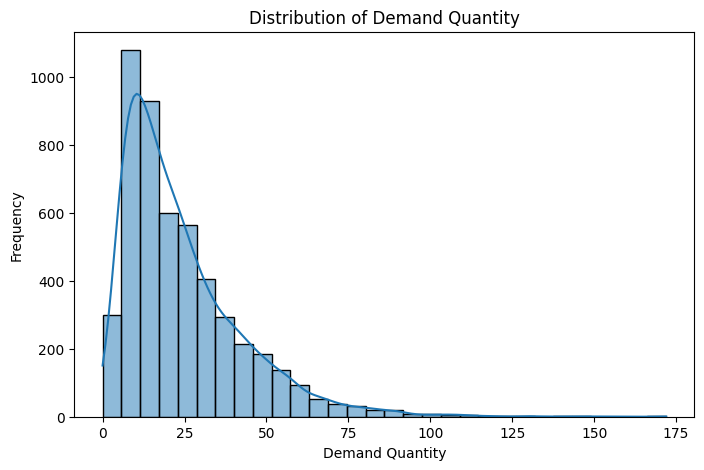

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Demand_Quantity"],
    bins=30,
    kde=True
)

plt.xlabel("Demand Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Demand Quantity")

plt.show()

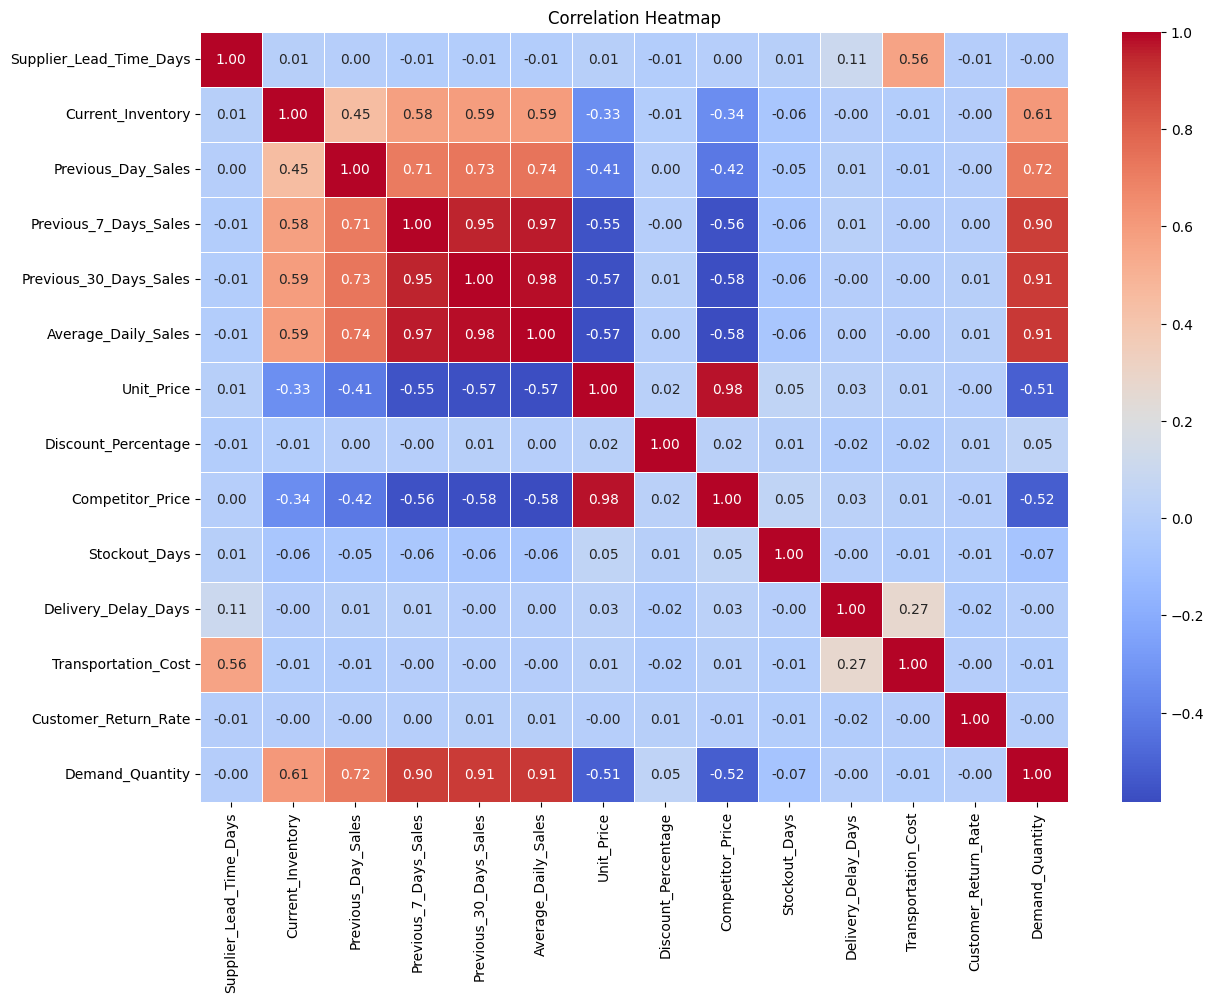

In [19]:
plt.figure(figsize=(14, 10))

correlation = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()